In [1]:
%load_ext autoreload
%autoreload 2
import os
import functools
from pathlib import Path
import numpy as np

import re
import matplotlib.pyplot as plt

imginfo = lambda img: print(type(img), img.dtype, img.shape, img.min(), img.max())


os.environ["CUDA_VISIBLE_DEVICES"]="0"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
return_depth = False

dataset_location = "./data/clevr-real-block-v3"
dataset_location = Path(dataset_location)

model_location = Path("./data/models/")
model_path = model_location / "clevr-act-7-depth_text_aug" / "checkpoint-4687"

save_folder = "./data/prediction/"
Path(save_folder).mkdir(parents=True, exist_ok=True)

if "depth_depth_l40" in str(model_path):
    return_depth = True

print("dataset_location", dataset_location)
if model_path.is_dir():
    print("moadel_path is", model_path)

dataset_location data/clevr-real-block-v3
moadel_path is data/models/clevr-act-7-depth_text_aug/checkpoint-4687


dataset len 160
160


  0%|          | 0/3 [00:00<?, ?it/s]

(1280, 720)
(1280, 720)
(1280, 720)



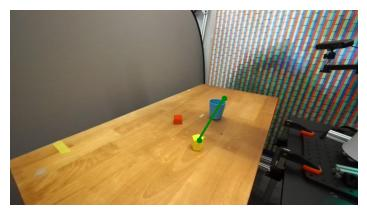
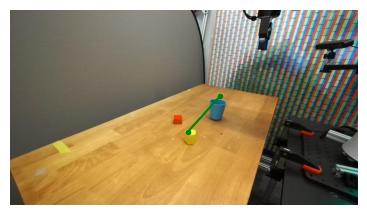
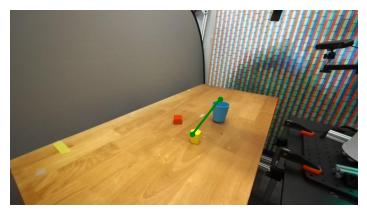

In [2]:
from data_loader_jsonl import JSONLDataset, ValidDataset
from data_augmentations import CropStart, CropMiddle, CropCenter


test_dataset = JSONLDataset(
    jsonl_file_path=f"{dataset_location}/_annotations.valid.jsonl",
    image_directory_path=f"{dataset_location}/dataset",
    clean_prompt=True,
    #augment_crop=CropStart(crop_size=1300, valid=False),
    #augment_crop=CropMiddle(crop_size=500, object_size=20, valid=True),
    #augment_crop=CropCenter(crop_size=500, valid=False),
    return_depth=return_depth
)

print("dataset len", len(test_dataset))

from IPython.display import display, HTML
from tqdm.notebook import tqdm
from utils_vis import render_example

def get_image(images):
    if isinstance(images, (list, tuple)):
        return images[-1]
    else:
        return images
    
def get_depth(images):
    if isinstance(images, (list, tuple)):
        return images[0]
    else:
        return None
    
print(len(test_dataset))
num_samples = 3
html_imgs = ""
for i in tqdm(range(num_samples)):
    images, sample = test_dataset[i]
    image = get_depth(images) if return_depth else get_image(images)
    print(image.size)
    html_imgs += render_example(image, label=sample["suffix"], text=sample["prefix"], camera=sample["camera"])
    
display(HTML(html_imgs))

In [3]:
import torch
from transformers import PaliGemmaProcessor, PaliGemmaForConditionalGeneration

DEVICE = 'cuda' # torch.device('cuda' if torch.cuda.is_available() else 'cpu')
TORCH_DTYPE = torch.bfloat16
print('Using device:', DEVICE)


MODEL_ID ="google/paligemma2-3b-pt-224"
processor = PaliGemmaProcessor.from_pretrained(MODEL_ID)
print("loaded processor.")
#model = PaliGemmaForConditionalGeneration.from_pretrained(model_path, torch_dtype=TORCH_DTYPE, device_map="auto")

def collate_fn(batch):
    images, labels = zip(*batch)
    prefixes = ["<image>" + label["prefix"] for label in labels]
    inputs = processor(
        text=prefixes,
        images=images,
        return_tensors="pt",
        padding="longest"
    ).to(TORCH_DTYPE).to(DEVICE)
    return inputs

Using device: cuda
loaded processor.


## Generate for all crop sizes

In [12]:
import math
from data_loader_jsonl import JSONLDataset, ValidDataset
from data_augmentations import CropStart, CropMiddle, CropCenter
from utils_maxim import save_model_output

save_folder = "./data/prediction/"
Path(save_folder).mkdir(parents=True, exist_ok=True)
model = PaliGemmaForConditionalGeneration.from_pretrained(model_path, torch_dtype=TORCH_DTYPE, device_map="auto")

crop_types = ["start_novalid", "start_valid", "middle_novalid", "middle_valid", "center_novalid", "center_valid"]



for crop_i in range(len(crop_types)):
    for crop_size in range(500, 1400, 100):
        crop_augmentation = [
            CropStart(crop_size=crop_size, valid=False),
            CropStart(crop_size=crop_size, valid=True),
            CropMiddle(crop_size=crop_size, object_size=20, valid=False),
            CropMiddle(crop_size=crop_size, object_size=20, valid=True),
            CropCenter(crop_size=crop_size, valid=False),
            CropCenter(crop_size=crop_size, valid=True),
        ]
        
        test_dataset = JSONLDataset(
            jsonl_file_path=f"{dataset_location}/_annotations.valid.jsonl",
            image_directory_path=f"{dataset_location}/dataset",
            clean_prompt=True,
            #augment_crop=CropCenter(crop_size=crop_size, valid=False),
            augment_crop=crop_augmentation[crop_i],
            return_depth=return_depth
        )
        
        print("dataset len", len(test_dataset))
    
        eval_batch_size = 1
        test_samples = len(test_dataset)
        #test_samples = 1
    
        pred_list = []
        html_imgs = ""
        for start_idx in tqdm(range(0, test_samples, eval_batch_size), total=math.ceil(test_samples / eval_batch_size)):
            episode_indices = range(start_idx, min(start_idx + eval_batch_size, test_samples))
            batch = [test_dataset[i] for i in episode_indices]
            #for e in batch:
            #    augment_sample(e)
            inputs = collate_fn(batch) # inspect with inputs.keys()
            prefix_length = inputs["input_ids"].shape[-1]    
        
            with torch.inference_mode():
                generation = model.generate(**inputs, max_new_tokens=12, do_sample=False, use_cache=False, 
                                            return_dict_in_generate=True, output_scores=True)
                # inspect with generation.keys()
                decoded = [processor.decode(x, skip_special_tokens=True) for x in generation.sequences[:, prefix_length:]]
            pred_list.extend(decoded)
        
            
            for batch_entry, decoded_str, episode_i in zip(batch, decoded, episode_indices):
                image, sample = batch_entry
    
                # === save model output
                save_folder = f"./data/crop_runs/{crop_types[crop_i]}/"
                Path(save_folder).mkdir(parents=True, exist_ok=True)
                file = save_folder + f"tokens_{episode_i:04d}_{crop_size:04d}.npy"
                save_model_output(generation, file)

dataset len 160


  0%|          | 0/160 [00:00<?, ?it/s]

dataset len 160


  0%|          | 0/160 [00:00<?, ?it/s]

dataset len 160


...

  0%|          | 0/160 [00:00<?, ?it/s]

dataset len 160


  0%|          | 0/160 [00:00<?, ?it/s]

dataset len 160


  0%|          | 0/160 [00:00<?, ?it/s]

In [16]:
# check saved distribution

save_folder = "./data/crop_runs/start_novalid/"
Path(save_folder).mkdir(parents=True, exist_ok=True)

with open(save_folder + "tokens_0000_0500.npy", "rb") as f:
    sequences = np.load(f)
    scores = np.load(f)
print("predicted text:")
print(sequences.shape)
decoded_str = processor.decode(sequences[0], skip_special_tokens=True).split('\n')[1]
print(decoded_str)
print("---")

print("predicted distribution")
print(scores.shape)
print("---")

predicted text:
(1, 285)
<loc0541><loc0500><loc0047><seg052><seg060><seg030><loc0155><loc0651><loc0059><seg052><seg060><seg030>
---
predicted distribution
(12, 1, 1024)
---


Text(0.5, 0, 'x')

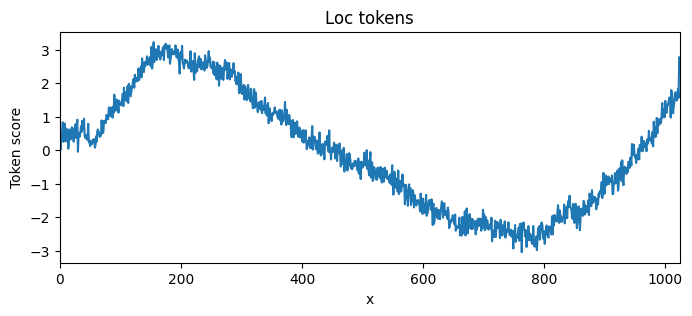

In [17]:
from utils_maxim import softmax

token_pos = 6 # obj_start (h w d rv0 rv1 rv2), obj_end (h w d rv0 rv1 rv2)

probas = scores[token_pos, 0]
#probas[np.isinf(probas)] = 0
#probas = softmax(probas, 2.0)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(np.arange(0, 1024), probas)
ax.set_xlim(0, 1024)
ax.set_ylabel("Token score")
ax.set_title("Loc tokens")
ax.set_xlabel("x")

## Evaluate

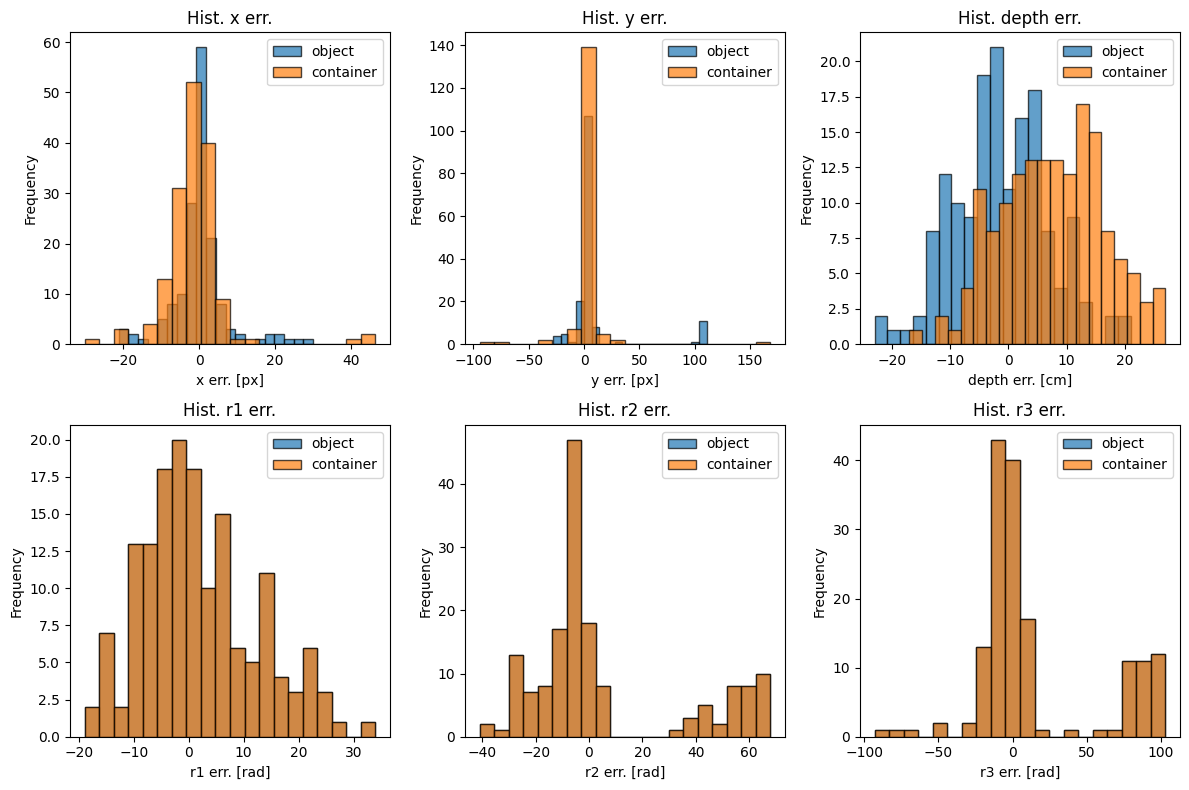

Valid Samples: 158 L1: 13.297995780590718

L1_depth 6.715189873417722


In [44]:
import re
import numpy as np
import matplotlib.pyplot as plt

# Compute results from pred_list = [decoded str i, ...]

save_folder = "./data/crop_runs/start_novalid/"
crop_size = 800

# Load dataset
test_dataset = JSONLDataset(
    jsonl_file_path=f"{dataset_location}/_annotations.valid.jsonl",
    image_directory_path=f"{dataset_location}/dataset",
    clean_prompt=True,
    augment_crop=CropStart(crop_size=crop_size, valid=False),
    #augment_crop=CropMiddle(crop_size=crop_size, object_size=20, valid=True),
    #augment_crop=CropCenter(crop_size=crop_size, valid=False),
    return_depth=return_depth
)

# Define episodes
test_samples = len(test_dataset)
sample_list = list(range(test_samples))
#sample_list = [0, 1]

pred_list = []
for episode_i in sample_list:
    with open(save_folder + f"tokens_{episode_i:04d}_{crop_size:04d}.npy", "rb") as f:
        sequences = np.load(f)
        scores =  np.load(f)
    decoded_str = processor.decode(sequences[0], skip_special_tokens=True).split('\n')[1]
    pred_list.append(decoded_str)

# Max part
results = []
for i, pred in enumerate(pred_list):
    suffix = test_dataset[i][1]["suffix"]
    suffix_p = [int(x) for x in re.findall(r"<(?:loc|seg)(-?\d+)>", suffix)]
    decode_p = [int(x) for x in re.findall(r"<(?:loc|seg)(-?\d+)>", pred)]
    if len(suffix_p) != 12 or len(decode_p) != 12:
        continue

    suffix_p = np.array(suffix_p, dtype=float)
    decode_p = np.array(decode_p, dtype=float)

    # maniskill (1024, 1024) to (image_height, image_width)
    image = test_dataset[i][0]
    h, w = image.size
    #suffix_p[[0, 6]] *= h/1024
    #suffix_p[[1, 7]] *= w/1024

    #decode_p[[0, 6]] *= h/1024
    #decode_p[[1, 7]] *= w/1024
    
    pred_diff = np.array(suffix_p) - np.array(decode_p)
    results.append(pred_diff)
results = np.array(results)

results[:, 0:2] = results[:, 0:2]/1024*224 
results[:, 6:8] = results[:, 6:8]/1024*224 


keypoint = ["object","container"]
action_labels = ["x","y","depth","r1","r2","r3"]*2
units         = ["px","px","cm","rad","rad","rad"]*2
plot_hist=True
if plot_hist:
    fig, axes = plt.subplots(2, 3, figsize=(12, 12*2/3))  # 3 rows x 4 columns of histograms
    axes = axes.flatten()  # Flatten the 2D array of axes for easy iteration
    for i in range(2):
        for j in range(6):
            axes[j].hist(results[:, i*6+j], bins=20, alpha=0.7,  edgecolor='black', label=keypoint[i])
            axes[j].set_title(f'Hist. {action_labels[j]} err.')
            axes[j].set_xlabel(f"{action_labels[j]} err. [{units[j]}]")
            axes[j].set_ylabel('Frequency')
            axes[j].legend()
    plt.tight_layout()  # Adjust layout for better spacing
    plt.show()

print("Valid Samples:", len(results), "L1:",np.mean(np.abs(results)))
print()
print("L1_depth", np.mean(np.abs(results[:,2])))

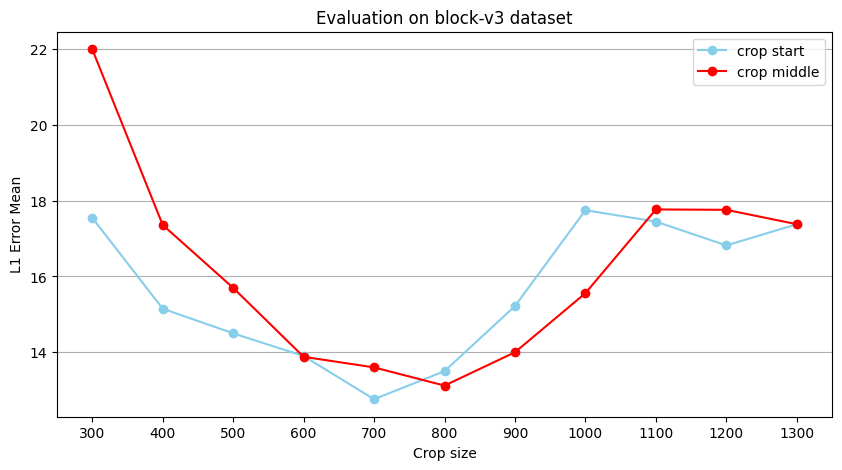

In [8]:
# All of this is not very correct


# on crop less than 500 the cup is not visible
eval_on_crops = {"1300":17.38, "1200":16.82, "1100":17.45, "1000":17.75, "900":15.22, "800":13.5, "700":12.76,
                "600":13.9, "500":14.5, "400":15.15, "300":17.55}
eval_middle_crops = {
    "1300": 17.38, "1200": 17.76, "1100": 17.77, "1000": 15.56, "900": 14.0, "800": 13.12, 
    "700": 13.6, "600": 13.88, "500": 15.7, "400": 17.36, "300": 22.0
}

# Extract labels and values
labels, values = zip(*eval_on_crops.items())
_, values_middle = zip(*eval_middle_crops.items())

labels = labels[::-1]
values = values[::-1]
values_middle = values_middle[::-1]

# plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(labels, values, 'o-', color='skyblue', label='crop start')
ax.plot(labels, values_middle, 'o-', color='red', label='crop middle')

ax.set_ylabel("L1 Error Mean")
ax.set_title("Evaluation on block-v3 dataset")
#ax.set_xticks(rotation=45, ha="right")
ax.set_xlabel("Crop size")
ax.grid(axis="y")
ax.legend()

#fig.savefig("fig.png")

## Evaluate all crops from precomputed

In [43]:
crop_types = ["start_novalid", "start_valid", "middle_novalid", "middle_valid", "center_novalid", "center_valid"]

def eval_from_precomputed(crop_i, crop_size):
    global crop_types
    # Compute results from pred_list = [decoded str i, ...]

    crop_augmentation = [
        CropStart(crop_size=crop_size, valid=False),
        CropStart(crop_size=crop_size, valid=True),
        CropMiddle(crop_size=crop_size, object_size=20, valid=False),
        CropMiddle(crop_size=crop_size, object_size=20, valid=True),
        CropCenter(crop_size=crop_size, valid=False),
        CropCenter(crop_size=crop_size, valid=True),
    ]

    save_folder = f"./data/crop_runs/{crop_types[crop_i]}/"
    
    # Load dataset
    test_dataset = JSONLDataset(
        jsonl_file_path=f"{dataset_location}/_annotations.valid.jsonl",
        image_directory_path=f"{dataset_location}/dataset",
        clean_prompt=True,
        #augment_crop=CropMiddle(crop_size=crop_size, object_size=20, valid=True),
        augment_crop=crop_augmentation[crop_i],
        return_depth=return_depth
    )
    
    # Define episodes
    test_samples = len(test_dataset)
    sample_list = list(range(test_samples))
    #sample_list = [0, 1]
    
    pred_list = []
    for episode_i in sample_list:
        with open(save_folder + f"tokens_{episode_i:04d}_{crop_size:04d}.npy", "rb") as f:
            sequences = np.load(f)
            scores =  np.load(f)
        decoded_str = processor.decode(sequences[0], skip_special_tokens=True).split('\n')[1]
        pred_list.append(decoded_str)
    
    # Max part
    results = []
    for i, pred in enumerate(pred_list):
        suffix = test_dataset[i][1]["suffix"]
        suffix_p = [int(x) for x in re.findall(r"<(?:loc|seg)(-?\d+)>", suffix)]
        decode_p = [int(x) for x in re.findall(r"<(?:loc|seg)(-?\d+)>", pred)]
        if len(suffix_p) != 12 or len(decode_p) != 12:
            continue
    
        suffix_p = np.array(suffix_p, dtype=float)
        decode_p = np.array(decode_p, dtype=float)
    
        # maniskill (1024, 1024) to (image_height, image_width)
        image = test_dataset[i][0]
        h, w = image.size
        suffix_p[[0, 6]] *= h/1024
        suffix_p[[1, 7]] *= w/1024
    
        decode_p[[0, 6]] *= h/1024
        decode_p[[1, 7]] *= w/1024
        
        pred_diff = np.array(suffix_p) - np.array(decode_p)
        results.append(pred_diff)
    results = np.array(results)
    return results

all_l1 = [] # (crop_type, crop_size)
for crop_i in range(len(crop_types)):
    crop_l1 = []
    for crop_size in range(500, 1400, 100):
        print(crop_types[crop_i], crop_size)
        results = eval_from_precomputed(crop_i, crop_size)
        crop_l1.append(np.mean(np.abs(results)))
    all_l1.append(crop_l1)


start_novalid 500
start_novalid 600
start_novalid 700
start_novalid 800
start_novalid 900
start_novalid 1000
start_novalid 1100
start_novalid 1200
start_novalid 1300
start_valid 500
start_valid 600
start_valid 700
start_valid 800
start_valid 900
start_valid 1000
start_valid 1100
start_valid 1200
start_valid 1300
middle_novalid 500
middle_novalid 600
middle_novalid 700
middle_novalid 800
middle_novalid 900
middle_novalid 1000
middle_novalid 1100
middle_novalid 1200
middle_novalid 1300
middle_valid 500
middle_valid 600
middle_valid 700
middle_valid 800
middle_valid 900
middle_valid 1000
middle_valid 1100
middle_valid 1200
middle_valid 1300
center_novalid 500
center_novalid 600
center_novalid 700
center_novalid 800
center_novalid 900
center_novalid 1000
center_novalid 1100
center_novalid 1200
center_novalid 1300
center_valid 500
center_valid 600
center_valid 700
center_valid 800
center_valid 900
center_valid 1000
center_valid 1100
center_valid 1200
center_valid 1300


In [9]:
start_novalid = 0
start_valid = 1
crop_900 = 4
print(all_l1[start_novalid][crop_900])
print(all_l1[start_valid][crop_900])

26.174253336588542
24.89012272342755


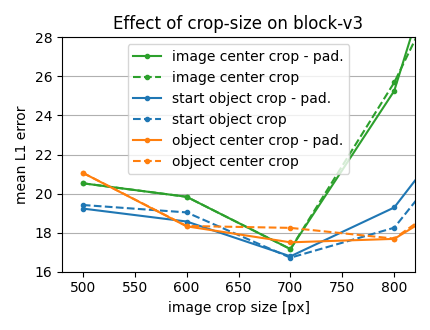

In [41]:
import matplotlib

# plot
labels = np.arange(500, 1400, 100)
crop_labels = ["start object crop - pad.", "start object crop",
               "object center crop - pad.", "object center crop",
               "image center crop - pad.", "image center crop"]

fig, ax = plt.subplots(figsize=(4.3, 3.3))
ax.plot(labels, all_l1[4], '.-', color='tab:green', label=crop_labels[4])
ax.plot(labels, all_l1[5], '.--', color='tab:green', label=crop_labels[5])
ax.plot(labels, all_l1[0], '.-', color='tab:blue', label=crop_labels[0])
ax.plot(labels, all_l1[1], '.--', color='tab:blue', label=crop_labels[1])
ax.plot(labels, all_l1[2], '.-', color='tab:orange', label=crop_labels[2])
ax.plot(labels, all_l1[3], '.--', color='tab:orange', label=crop_labels[3])


ax.set_ylabel("mean L1 error")
ax.set_title("Effect of crop-size on block-v3")
#ax.set_xticks(rotation=45, ha="right")
ax.set_xlabel("image crop size [px]")
ax.set_xlim((480, 820))
ax.set_ylim((16, 28))
ax.grid(axis="y")
ax.legend()
fig.tight_layout()
fig.savefig("effect_of_crop_size_block_v3.pdf")
plt.show()

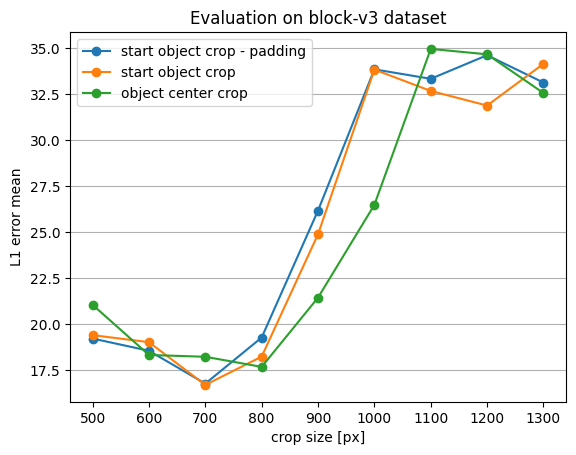

In [11]:
# plot
labels = np.arange(500, 1400, 100)

fig, ax = plt.subplots()
ax.plot(labels, all_l1[0], 'o-', label=crop_labels[0])
ax.plot(labels, all_l1[1], 'o-', label=crop_labels[1])
ax.plot(labels, all_l1[3], 'o-', label=crop_labels[3])

ax.set_ylabel("L1 error mean")
ax.set_title("Evaluation on block-v3 dataset")
#ax.set_xticks(rotation=45, ha="right")
ax.set_xlabel("crop size [px]")
ax.grid(axis="y")
ax.legend()
#fig.savefig("fig.png")

## Pictures

Load precomputed token distribution.

The text field is cleared after you press a letter.
asdf - prev 10, prev, next, next 10



interactive(children=(Text(value='', description='String:', placeholder='Type something'), Output()), _dom_cla…

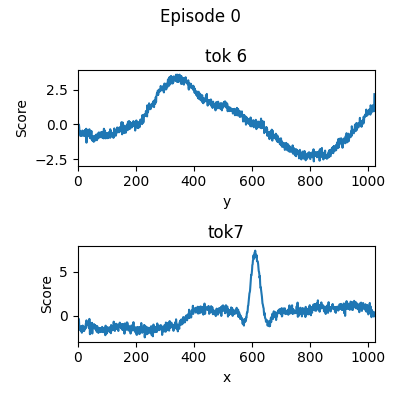

In [96]:
%matplotlib widget
from ipywidgets import widgets, Layout, interact
from IPython.display import display, HTML
from utils_maxim import softmax

save_folder = "./data/crop_runs/start_valid/"
crop_size = 700

helpstr = """The text field is cleared after you press a letter.
asdf - prev 10, prev, next, next 10
"""
print(helpstr)

test_dataset = JSONLDataset(
    jsonl_file_path=f"{dataset_location}/_annotations.valid.jsonl",
    image_directory_path=f"{dataset_location}/dataset",
    clean_prompt=True,
    augment_crop=CropStart(crop_size=crop_size, valid=True),
    return_depth=return_depth
)

# interactive image
episode_i = 0

def update(w: int):
    global episode_i
    global fig, axs

    mode = "keyboard"
    if mode == "keyboard":
        # === keyboard control
        if w == "":
            pass
        else:
            if w == "a":
                episode_i = max(0, episode_i - 10)
            elif w == "s":
                episode_i = max(0, episode_i - 1)
            elif w == "d":
                episode_i = min(len(test_dataset)-1, episode_i+1)
            elif w == "f":
                episode_i = min(len(test_dataset)-1, episode_i+10)
        text_w.value = "" # Reset text field
    elif mode == "slider":
        # === slider control
        episode_i = w
    
    # load episode
    image, sample = test_dataset[episode_i]
    with open(save_folder + f"tokens_{episode_i:04d}_{crop_size:04d}.npy", "rb") as f:
        sequences = np.load(f)
        scores =  np.load(f)
    decoded_str = processor.decode(sequences[0], skip_special_tokens=True).split('\n')[1]

    # obj_start (h w d rv0 rv1 rv2), obj_end (h w d rv0 rv1 rv2)
    loc_h, scores_h = np.arange(0, 1024), scores[6, 0] # CHANGE ME
    loc_w, scores_w = np.arange(0, 1024), scores[7, 0]
    #scores_h = softmax(scores_h)
    #scores_w = softmax(scores_w)

    # === show image
    html_img = render_example(image, text=sample["prefix"], label=sample["suffix"], prediction=decoded_str, camera=sample["camera"])
    display(HTML(html_img), clear=True)

    # === plot token distribution #1
    fig.suptitle("Episode " + str(episode_i))
    ax = axs[0]
    ax.clear()
    ax.plot(np.arange(0, 1024), scores_h)
    ax.set_xlim(0, 1024)
    ax.set_ylabel("Score")
    ax.set_title("tok 6")
    ax.set_xlabel("y")

    # find local maxima
    # n = 100  # number of points to be checked before and after
    # max_ind = [i for (val, i) in find_local_maxima(scores_h, n)]
    # ax.scatter(max_ind[:2], scores_h[max_ind[:2]], color='red')

    # === plot token distribution #2
    ax = axs[1]
    ax.clear()
    ax.plot(np.arange(0, 1024), scores_w)
    ax.set_xlim(0, 1024)
    ax.set_ylabel("Score")
    ax.set_title("tok7")
    ax.set_xlabel("x")

    # find local maxima
    # n = 100  # number of points to be checked before and after
    # max_ind = [i for (val, i) in find_local_maxima(scores_w, n)]
    # ax.scatter(max_ind[:2], scores_w[max_ind[:2]], color='red')

    fig.tight_layout()

    

image_width, image_height = int(400), int(400)
dpi = 100
figsize = (image_width / dpi, image_height / dpi)
fig, axs = plt.subplots(2, 1, figsize=figsize, dpi=dpi)
axs[0].set_axis_off()
axs[1].set_axis_off()

text_w = widgets.Text(
    value="",
    placeholder="Type something",
    description="String:",
    disabled=False   
)

# === Slider widget
slider_w = widgets.IntSlider(min=0, max=len(test_dataset)-1, step=3, value=0, layout=Layout(width="70%"))
#interact(update, w=slider_w)

# === Key press widget
interact(update, w=text_w)
pass

## One picture


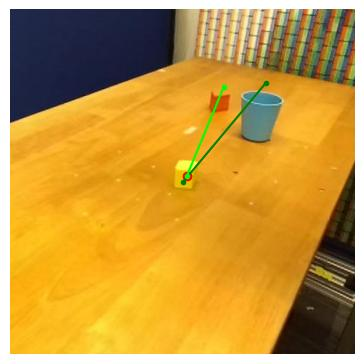

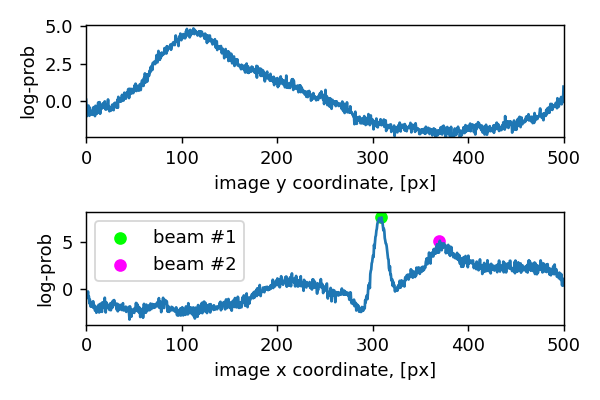

In [15]:
%matplotlib widget
from ipywidgets import widgets, Layout, interact
from IPython.display import display, HTML
from utils_maxim import softmax, maxima_ind

save_folder = "./data/crop_runs/start_valid/"
crop_size = 500

test_dataset = JSONLDataset(
    jsonl_file_path=f"{dataset_location}/_annotations.valid.jsonl",
    image_directory_path=f"{dataset_location}/dataset",
    clean_prompt=True,
    augment_crop=CropStart(crop_size=crop_size, valid=True),
    return_depth=return_depth
)

episode_i = 81

def plot():
    global episode_i
    global fig, axs
    
    # load episode
    image, sample = test_dataset[episode_i]
    with open(save_folder + f"tokens_{episode_i:04d}_{crop_size:04d}.npy", "rb") as f:
        sequences = np.load(f)
        scores =  np.load(f)
    decoded_str = processor.decode(sequences[0], skip_special_tokens=True).split('\n')[1]

    # obj_start (h w d rv0 rv1 rv2), obj_end (h w d rv0 rv1 rv2)
    loc_h, scores_h = np.arange(0, 1024), scores[6, 0] # CHANGE ME
    loc_w, scores_w = np.arange(0, 1024), scores[7, 0]
    #scores_h = softmax(scores_h)
    #scores_w = softmax(scores_w)

    # === show image
    html_img = render_example(image, text=sample["prefix"], label=sample["suffix"], prediction=decoded_str, camera=sample["camera"])
    display(HTML(html_img), clear=True)

    # === plot token distribution #1
    #fig.suptitle("Episode " + str(episode_i))
    ax = axs[0]
    ax.clear()
    h, w = image.size
    ax.plot(np.linspace(0, h, 1024), scores_h) # range(0, 1024)
    ax.set_xlim(0, h)
    ax.set_ylim(-2.4, 5.1)
    #ax.set_yticks(["","0","2","4"])
    ax.set_ylabel("log-prob")
    #ax.set_title("Distribution of image y coordinate")
    ax.set_xlabel("image y coordinate, [px]")

    # === find local maxima
    # n = 100  # number of points to be checked before and after
    # ind = maxima_ind(scores_w, n)
    # ax.scatter(ind[0], scores_w[ind[0]], color='lime')
    # ax.scatter(ind[1], scores_w[ind[1]], color='magenta')

    # === plot token distribution #2
    ax = axs[1]
    ax.clear()
    ax.plot(np.linspace(0, w, 1024), scores_w) # range(0, 1024)
    ax.set_xlim(0, w)
    #ax.set_ylim(-2.4, 5.1)
    ax.set_ylabel("log-prob")
    #ax.set_title("Distribution of image x coordinate")
    ax.set_xlabel("image x coordinate, [px]")

    # === find local maxima
    n = 100  # number of points to be checked before and after
    ind = maxima_ind(scores_w, n)
    ax.scatter(ind[0]*w/1024, scores_w[ind[0]], color='lime', label='beam #1')
    ax.scatter(ind[1]*w/1024, scores_w[ind[1]], color='magenta', label='beam #2')
    ax.legend()

    fig.tight_layout()
    fig.savefig('distrib-81-crop-500.pdf')

image_width, image_height = 600, 400
dpi = 130
figsize = (image_width / dpi, image_height / dpi)
fig, axs = plt.subplots(2, 1, figsize=figsize, dpi=dpi)
axs[0].set_axis_off()
axs[1].set_axis_off()

plot()

## Test local max

In [5]:
from scipy.signal import argrelextrema
from utils_maxim import softmax

save_folder = "./data/crop_runs/start_novalid/"
episode_i = 0
crop_size = 500

with open(save_folder + f"tokens_{episode_i:04d}_{crop_size:04d}.npy", "rb") as f:
    sequences = np.load(f)
    scores = np.load(f)

print("predicted text:")
print(sequences.shape)
decoded_str = processor.decode(sequences[0], skip_special_tokens=True).split('\n')[1]
print(decoded_str)
print("---")

print("predicted distribution")
print(scores.shape)
print("---")

predicted text:
(1, 285)
<loc0541><loc0500><loc0047><seg052><seg060><seg030><loc0155><loc0651><loc0059><seg052><seg060><seg030>
---
predicted distribution
(12, 1, 1024)
---


[155, 1023]


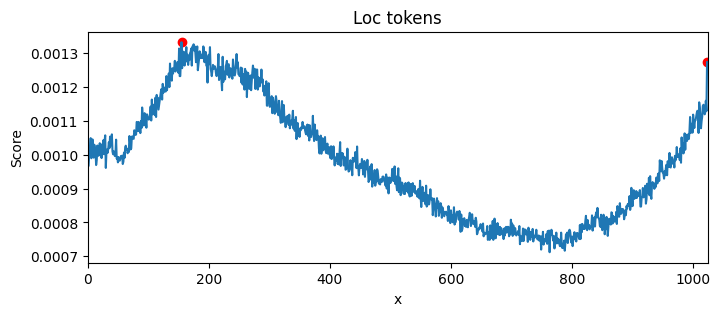

In [6]:
token_pos = 6 # 0 - start y, 1 - start x, 6 - end y, 7 - end x
probas = scores[token_pos, 0]
probas = softmax(probas, 10.0)

fig, ax = plt.subplots(figsize=(8, 3))
#ax.scatter(tokens, probas, color='skyblue', alpha=0.3)
ax.plot(np.arange(0, 1024), probas)
ax.set_xlim(0, 1024)
ax.set_ylabel("Score")
ax.set_title("Loc tokens")
ax.set_xlabel("x")

# find local maxima
n = 100  # number of points to be checked before and after
max_ind = argrelextrema(probas, np.greater_equal, order=n)[0]

# Achtung! Suppress close points with same value
res = [max_ind[0]]
for ind in max_ind:
    if ind - res[-1] > n:
        res.append(ind)
max_ind = res
print(max_ind)

# plot local maxima
ax.scatter(max_ind, probas[max_ind], color='red')

In [9]:
# problem with argrelextrema: local maxima with identical values get preserved

import numpy as np
from scipy.signal import argrelextrema
x = np.array([3, 3, 0, 1, 0, 0])
assert np.all(
    argrelextrema(x, np.greater_equal, order=2)[0] == [0, 1]
)